<a href="https://colab.research.google.com/github/Mounika-Kola/Weather-Prediction-using-Traditional-Machine-Learning-Algorithms-and-Neural-Networks/blob/main/Temperature_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAX_TEMPERATURE PREDICTION USING LINEAR REGRESSION**

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,KFold,GridSearchCV
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from scipy.stats import uniform
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,r2_score
from torch.utils.data import DataLoader, TensorDataset

In [76]:
data=pd.read_csv("/content/weather.csv")
data.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='object')

In [77]:
data = data.drop(columns=['WindGustDir','WindDir9am', 'WindDir3pm','RainTomorrow'])

In [78]:
data.shape

(366, 18)

In [79]:
data.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM
0,8.0,24.3,0.0,3.4,6.3,30.0,6.0,20,68,29,1019.7,1015.0,7,7,14.4,23.6,No,3.6
1,14.0,26.9,3.6,4.4,9.7,39.0,4.0,17,80,36,1012.4,1008.4,5,3,17.5,25.7,Yes,3.6
2,13.7,23.4,3.6,5.8,3.3,85.0,6.0,6,82,69,1009.5,1007.2,8,7,15.4,20.2,Yes,39.8
3,13.3,15.5,39.8,7.2,9.1,54.0,30.0,24,62,56,1005.5,1007.0,2,7,13.5,14.1,Yes,2.8
4,7.6,16.1,2.8,5.6,10.6,50.0,20.0,28,68,49,1018.3,1018.5,7,7,11.1,15.4,Yes,0.0


In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        366 non-null    float64
 1   MaxTemp        366 non-null    float64
 2   Rainfall       366 non-null    float64
 3   Evaporation    366 non-null    float64
 4   Sunshine       363 non-null    float64
 5   WindGustSpeed  364 non-null    float64
 6   WindSpeed9am   359 non-null    float64
 7   WindSpeed3pm   366 non-null    int64  
 8   Humidity9am    366 non-null    int64  
 9   Humidity3pm    366 non-null    int64  
 10  Pressure9am    366 non-null    float64
 11  Pressure3pm    366 non-null    float64
 12  Cloud9am       366 non-null    int64  
 13  Cloud3pm       366 non-null    int64  
 14  Temp9am        366 non-null    float64
 15  Temp3pm        366 non-null    float64
 16  RainToday      366 non-null    object 
 17  RISK_MM        366 non-null    float64
dtypes: float64

In [81]:
data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,366.000000,366.000000,366.000000,366.000000,363.000000,364.000000,359.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,7.265574,20.550273,1.428415,4.521858,7.909366,39.840659,9.651811,17.986339,72.035519,44.519126,1019.709016,1016.810383,3.890710,4.024590,12.358470,19.230874,1.428415
std,6.025800,6.690516,4.225800,2.669383,3.481517,13.059807,7.951929,8.856997,13.137058,16.850947,6.686212,6.469422,2.956131,2.666268,5.630832,6.640346,4.225800
min,-5.300000,7.600000,0.000000,0.200000,0.000000,13.000000,0.000000,0.000000,36.000000,13.000000,996.500000,996.800000,0.000000,0.000000,0.100000,5.100000,0.000000
25%,2.300000,15.025000,0.000000,2.200000,5.950000,31.000000,6.000000,11.000000,64.000000,32.250000,1015.350000,1012.800000,1.000000,1.000000,7.625000,14.150000,0.000000
50%,7.450000,19.650000,0.000000,4.200000,8.600000,39.000000,7.000000,17.000000,72.000000,43.000000,1020.150000,1017.400000,3.500000,4.000000,12.550000,18.550000,0.000000
75%,12.500000,25.500000,0.200000,6.400000,10.500000,46.000000,13.000000,24.000000,81.000000,55.000000,1024.475000,1021.475000,7.000000,7.000000,17.000000,24.000000,0.200000
max,20.900000,35.800000,39.800000,13.800000,13.600000,98.000000,41.000000,52.000000,99.000000,96.000000,1035.700000,1033.200000,8.000000,8.000000,24.700000,34.500000,39.800000


In [82]:
data.isnull().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,3
WindGustSpeed,2
WindSpeed9am,7
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


In [83]:
encoder = LabelEncoder()
data['RainToday'] = encoder.fit_transform(data['RainToday'])

In [84]:
data['Sunshine']=data['Sunshine'].fillna(data['Sunshine'].mean())
data['WindSpeed9am']=data['WindSpeed9am'].fillna(data['WindSpeed9am'].mean())
data['WindGustSpeed']=data['WindGustSpeed'].fillna(data['WindGustSpeed'].mean())

In [85]:
data.isnull().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


In [86]:
data['RainToday']

,RainToday
0,0
1,1
2,1
3,1
4,1
...,...
361,0
362,0
363,0
364,0


In [87]:
x=data.drop('MaxTemp',axis=1)
y= data['MaxTemp']

In [88]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,shuffle=False)

In [89]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [90]:
model=LinearRegression()
lrmodel=model.fit(x_train_scaled,y_train)

print(f"Intercept of the model is {model.intercept_}")

model.coef_  #To show the coefficients of all the features

Intercept of the model is 20.810958904109576


array([-0.20206588,  0.05071567,  0.16614652,  0.42786409,  0.27164141,
       -0.15263821, -0.0923124 ,  0.04339538,  0.46630396,  0.30218665,
       -0.34585172,  0.04929852,  0.06731825,  0.90994337,  6.22195236,
       -0.20325947,  0.01045845])

In [91]:
#LINEAR REGRESSION SCORE
lrtrain=model.score(x_train_scaled,y_train)
lrtest=model.score(x_test_scaled,y_test)
print(f"Train:{lrtrain:.5f}")
print(f"Test:{lrtest:.5f}")

Train:0.98651
Test:0.98180


In [92]:
y_pred = model.predict(x_test_scaled)

In [93]:
y_train_pred = model.predict(x_train_scaled)

mse = mean_squared_error(y_train, y_train_pred)
print(f'Mean Squared Error for train data: {mse:.5f}')

mselr= mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error for test data: {mselr:.5f}')

Mean Squared Error for train data: 0.66742
Mean Squared Error for test data: 0.44158


Text(0.5, 0, 'Errors')

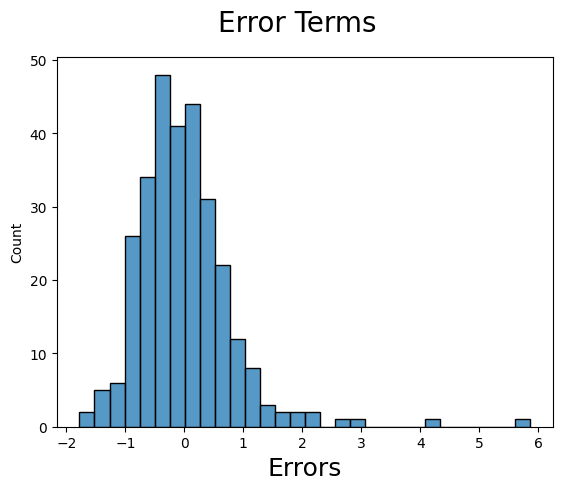

In [173]:
fig = plt.figure()
sns.histplot((y_train - y_train_pred), bins = 30)
fig.suptitle('Error Terms', fontsize = 20)
plt.xlabel('Errors', fontsize = 18)

Text(0.5, 0, 'Errors')

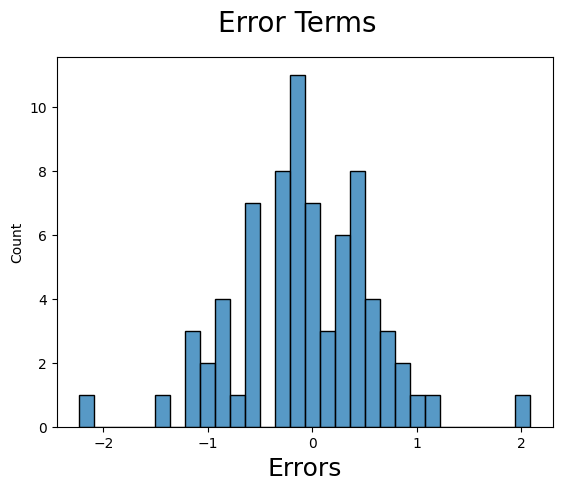

In [174]:
fig = plt.figure()
sns.histplot((y_test - y_pred), bins = 30)
fig.suptitle('Error Terms', fontsize = 20)
plt.xlabel('Errors', fontsize = 18)

Text(0, 0.5, 'y_pred')

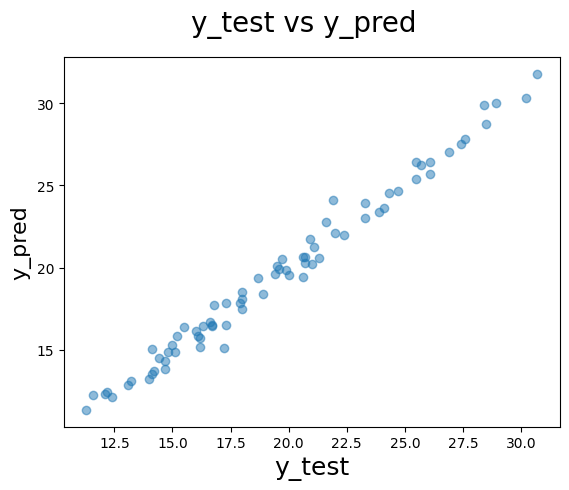

In [96]:
fig = plt.figure()
plt.scatter(y_test,y_pred,alpha=0.5)
fig.suptitle('y_test vs y_pred', fontsize=20)
plt.xlabel('y_test', fontsize=18)
plt.ylabel('y_pred', fontsize=16)



**LASSO REGRESSION (L1 Regularisation)**



In [97]:
#GridSearchCV
LassoRegression = Lasso()
hyperParameters = {'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
LassoRegressor = GridSearchCV(LassoRegression, hyperParameters, scoring='neg_mean_squared_error', cv=5)
LassoRegressor.fit(x_train_scaled,y_train)
print("Best value for lambda : ",LassoRegressor.best_params_)
print("Best score for cost function: ", LassoRegressor.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.106e+00, tolerance: 1.204e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.583e+01, tolerance: 1.227e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.337e+00, tolerance: 1.267e

Best value for lambda :  {'alpha': 0.01}
Best score for cost function:  -0.8493754578461198


In [98]:
lasso=Lasso(alpha=0.01)
larmodel=lasso.fit(x_train_scaled,y_train)
lasso.coef_

array([-0.00000000e+00,  2.30268718e-03,  1.04471667e-01,  3.53950139e-01,
        2.28924321e-01, -1.71580463e-01, -5.76181100e-02,  0.00000000e+00,
        3.87469483e-01,  0.00000000e+00, -7.02305775e-02,  4.24486921e-03,
        7.21149850e-02,  7.15549265e-01,  6.25326680e+00, -1.80229626e-01,
        2.11813112e-02])

In [99]:
#LASSO REGRESSION SCORE
lartrain=lasso.score(x_train_scaled,y_train)
lartest=lasso.score(x_test_scaled,y_test)
print(f"Train:{lartrain:.5f}")
print(f"Test:{lartest:.5f}")

Train:0.98631
Test:0.98292


In [100]:
y_lasso_pred = lasso.predict(x_test_scaled)

In [101]:
mselr= mean_squared_error(y_test, y_lasso_pred)
print(f'Mean Squared Error(Lasso): {mselr:.5f}')

Mean Squared Error(Lasso): 0.41422


Text(0, 0.5, 'y_lasso_pred')

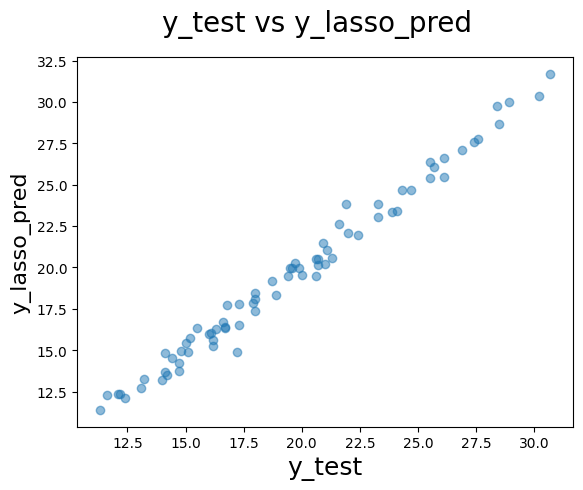

In [102]:
fig = plt.figure()
plt.scatter(y_test,y_lasso_pred,alpha=0.5)
fig.suptitle('y_test vs y_lasso_pred', fontsize=20)
plt.xlabel('y_test', fontsize=18)
plt.ylabel('y_lasso_pred', fontsize=16)

**RIDGE REGRESSION(L2 Regularization)**

In [103]:
#GridSearchCV
ridge=Ridge()
hyperParameters = {'alpha':[9e-1,8e-1,7e-1,6e-1,5e-1,4e-1,3e-1,2e-1,1e-1,1,5,10,15,20,25,30,35,40,45,50,55,60,70,80,90,100]}
ridgeRegressor = GridSearchCV(ridge, hyperParameters, scoring='neg_mean_squared_error', cv=5)
ridgeRegressor.fit(x_train_scaled,y_train)
print("Best value for lambda : ",ridgeRegressor.best_params_)
print("Best score for cost function: ", ridgeRegressor.best_score_)

Best value for lambda :  {'alpha': 0.6}
Best score for cost function:  -0.8630260625868733


In [104]:
ridge=Ridge(alpha=0.6)
rrmodel=ridge.fit(x_train_scaled,y_train)
ridge.coef_

array([-1.49136831e-01,  4.25915748e-02,  1.82186877e-01,  4.37879575e-01,
        2.73131376e-01, -1.78179450e-01, -1.14703085e-01,  7.72960019e-02,
        3.72016391e-01,  3.64886485e-01, -4.14372933e-01,  4.01216246e-02,
        6.43693293e-02,  1.03135909e+00,  5.97918944e+00, -1.97163229e-01,
        5.91630480e-03])

In [105]:
rrtrain=ridge.score(x_train_scaled,y_train)
rrtest=ridge.score(x_test_scaled,y_test)
print(f"Train:{rrtrain:.5f}")
print(f"Test:{rrtest:.5f}")

Train:0.98645
Test:0.98255


In [106]:
y_ridge_pred = ridge.predict(x_test_scaled)

In [107]:
mserr= mean_squared_error(y_test, y_ridge_pred)
print(f'Mean Squared Error(Ridge): {mserr:.5f}')

Mean Squared Error(Ridge): 0.42334


Text(0, 0.5, 'y_ridge_pred')

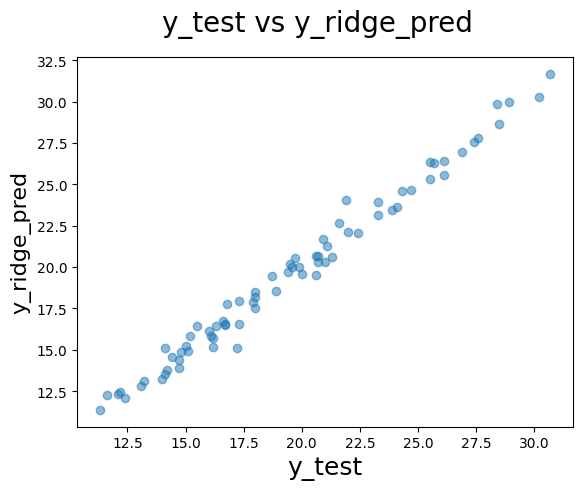

In [108]:
fig = plt.figure()
plt.scatter(y_test,y_ridge_pred,alpha=0.5)
fig.suptitle('y_test vs y_ridge_pred', fontsize=20)
plt.xlabel('y_test', fontsize=18)
plt.ylabel('y_ridge_pred', fontsize=16)

In [109]:
#COMPARISION AMONG LINEAR REGRESSION , LASSO REGRESSION, RIDGE REGRESSION
print(f'Mean Squared Error(Linear Regression): {mselr:.5f}')

print(f'Mean Squared Error(Lasso): {mselr:.5f}')

print(f'Mean Squared Error(Ridge): {mserr:.5f}')

Mean Squared Error(Linear Regression): 0.41422
Mean Squared Error(Lasso): 0.41422
Mean Squared Error(Ridge): 0.42334


**Elastic Net**

In [110]:
elastic_net = ElasticNet(random_state=42)
param_grid_elastic_net = {'alpha': [0.001,0.005,0.008,0.01,0.02,0.05,0.07, 0.1, 1, 10],'l1_ratio': [0.0,0.001,0.005,0.01,0.05,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,0.9, 1.0]}
rand_search_elastic_net = GridSearchCV(elastic_net,param_grid_elastic_net,cv=5,scoring='neg_mean_squared_error')
rand_search_elastic_net.fit(x_train_scaled, y_train)
print(f"Best parameters for ElasticNet: {rand_search_elastic_net.best_params_}")
print(f"Best MSE for ElasticNet: {-rand_search_elastic_net.best_score_}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.483e+01, tolerance: 1.204e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.998e+01, tolerance: 9.810e-01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

Best parameters for ElasticNet: {'alpha': 0.02, 'l1_ratio': 1.0}
Best MSE for ElasticNet: 0.8491699075512564


In [111]:
modelen= ElasticNet(alpha=0.02, l1_ratio=1.0)
modelen.fit(x_train_scaled, y_train)

ElasticNet(alpha=0.02, l1_ratio=1.0)

In [112]:
y_en_pred = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [113]:
entrain=modelen.score(x_train_scaled,y_train)
entest=modelen.score(x_test_scaled,y_test)
print(f"Train:{entrain:.5f}")
print(f"Test:{entest:.5f}")

Train:0.98613
Test:0.98256


In [114]:
mseen= mean_squared_error(y_test, y_en_pred)
print(f'Mean Squared Error(Elastic Net): {mseen:.5f}')

Mean Squared Error(Elastic Net): 13772.49750


**SUPPORT VECTOR REGRESSION(SVR)**

In [115]:
#GridSearchCV
param_grid = {'C': [0.1,0.5,0.3,0.9,1,5,8,10,15,20,25,40,80]}
grid = GridSearchCV(SVR(kernel='linear'), param_grid,cv=5,scoring='neg_mean_squared_error')
grid.fit(x_train_scaled, y_train)
print("Best Parameter:",grid.best_params_)

Best Parameter: {'C': 20}


In [116]:
svr=SVR(kernel='linear',C=0.9)
svrmodel=svr.fit(x_train_scaled,y_train)
svr.coef_

array([[ 0.09870686,  0.08984462,  0.06303092,  0.34966641,  0.27781618,
        -0.09410951, -0.19214844,  0.05010381,  0.1753923 ,  0.41341117,
        -0.48252295,  0.04238279,  0.09988077,  0.53435142,  6.22426077,
        -0.12810799, -0.01000499]])

In [117]:
y_svr_pred=svr.predict(x_test_scaled)

In [118]:
svrtrain=svr.score(x_train_scaled,y_train)
svrtest=svr.score(x_test_scaled,y_test)
print(f"Train:{svrtrain:.5f}")
print(f"Test:{svrtest:.5f}")

Train:0.98503
Test:0.98465


In [119]:
msesvr= mean_squared_error(y_test, y_svr_pred)
print(f'Mean Squared Error(SVR): {msesvr:.5f}')

Mean Squared Error(SVR): 0.37242


**DECISION TREE REGRESSION ALGORITHM**

In [120]:
tree=DecisionTreeRegressor()
tree.fit(x_train,y_train)

DecisionTreeRegressor()

In [121]:
y_tree_pred=tree.predict(x_test)

In [122]:
treetrain=tree.score(x_train,y_train)
treetest=tree.score(x_test,y_test)
print(f"Train:{treetrain:.5f}")
print(f"Test:{treetest:.5f}")

Train:1.00000
Test:0.93852


In [123]:
msetree= mean_squared_error(y_test, y_tree_pred)
print(f'Mean Squared Error(Decision Tree): {msetree:.5f}')

Mean Squared Error(Decision Tree): 1.49135


**CROSS VALIDATION**

In [124]:
#KFOLD
kf=KFold(n_splits=5, shuffle=True, random_state=42)

#PIPELINE
pipelr=Pipeline([('scaler',StandardScaler()),('regressor',LinearRegression())])
pipelar=Pipeline([('scaler',StandardScaler()),('lasso',Lasso(alpha=0.01))])
piperr=Pipeline([('scaler',StandardScaler()),('ridge',Ridge(alpha=0.5))])
pipesvr=Pipeline([('scaler',StandardScaler()),('SVR',SVR(kernel='linear',C=15))])
pipeen=Pipeline([('scaler',StandardScaler()),('Elastic Net',ElasticNet(alpha=0.01, l1_ratio=1.0))])

In [125]:
#LINEAR REGRESSION USING CROSS VALIDATION
#MSE
errors=cross_val_score(pipelr,x,y,cv=kf,scoring='neg_mean_squared_error')
print("Errors for Linear Regression model are:",errors)
ermn=-errors.mean()
print(f"Average error:{ermn:.5f}")

#Score
scores=cross_val_score(pipelr,x,y,cv=kf)
print("\nScores for Linear Regression model are:",scores)
scoresmean=scores.mean()
print(f"Average score:{scoresmean:.5f}")

Errors for Linear Regression model are: [-1.31020252 -0.59284013 -0.53043311 -0.66261144 -0.42599239]
Average error:0.70442

Scores for Linear Regression model are: [0.96904737 0.98793859 0.98711112 0.98564508 0.99015387]
Average score:0.98398


In [126]:
#LASSO REGRESSION USING CROSS VALIDATION
#MSE
errors=cross_val_score(pipelar,x,y,cv=kf,scoring='neg_mean_squared_error')
print("Errors for Lasso Regression model are:",errors)
ermn=-errors.mean()
print(f"Average error:{ermn:.5f}")

#Score
scores=cross_val_score(pipelar,x,y,cv=kf)
print("\nScores for Lasso Regression model are:",scores)
scoresmean=scores.mean()
print(f"Average score:{scoresmean:.5f}")

Errors for Lasso Regression model are: [-1.34351926 -0.55800996 -0.53224519 -0.64551571 -0.39321661]
Average error:0.69450

Scores for Lasso Regression model are: [0.96826028 0.98864721 0.98706709 0.98601544 0.99091143]
Average score:0.98418


In [127]:
#RIDGE REGRESSION USING CROSS VALIDATION
#MSE
errors=cross_val_score(piperr,x,y,cv=kf,scoring='neg_mean_squared_error')
print("Errors for Ridge Regression model are:",errors)
ermn=-errors.mean()
print(f"Average error:{ermn:.5f}")

#Score
scores=cross_val_score(piperr,x,y,cv=kf)
print("\nScores for Ridge Regression model are:",scores)
scoresmean=scores.mean()
print(f"Average score:{scoresmean:.5f}")

Errors for Ridge Regression model are: [-1.28889169 -0.59420335 -0.53379007 -0.6645211  -0.44159217]
Average error:0.70460

Scores for Ridge Regression model are: [0.96955082 0.98791085 0.98702955 0.9856037  0.98979331]
Average score:0.98398


In [128]:
#SUPPORT VECTOR REGRESSION USING CROSS VALIDATION
#MSE
errors=cross_val_score(pipesvr,x,y,cv=kf,scoring='neg_mean_squared_error')
print("Errors for Support Vector Regression model are:",errors)
ermn=-errors.mean()
print(f"Average error:{ermn:.5f}")

#Score
scores=cross_val_score(pipesvr,x,y,cv=kf)
print("\nScores for Support Vector Regression model are:",scores)
scoresmean=scores.mean()
print(f"Average score:{scoresmean:.5f}")

Errors for Support Vector Regression model are: [-1.42616967 -0.55475015 -0.51808408 -0.65868058 -0.35676091]
Average error:0.70289

Scores for Support Vector Regression model are: [0.96630772 0.98871353 0.98741119 0.98573023 0.99175404]
Average score:0.98398


In [129]:
#Elastic Net USING CROSS VALIDATION
#MSE
errors=cross_val_score(pipeen,x,y,cv=kf,scoring='neg_mean_squared_error')
print("Errors for Elastic Net are:",errors)
ermn=-errors.mean()
print(f"Average error:{ermn:.5f}")

#Score
scores=cross_val_score(pipeen,x,y,cv=kf)
print("\nScores for Elastic Net are:",scores)
scoresmean=scores.mean()
print(f"Average score:{scoresmean:.5f}")

Errors for Elastic Net are: [-1.34351926 -0.55800996 -0.53224519 -0.64551571 -0.39321661]
Average error:0.69450

Scores for Elastic Net are: [0.96826028 0.98864721 0.98706709 0.98601544 0.99091143]
Average score:0.98418


In [130]:
#DECISION TREE REGRESSION USING CROSS VALIDATION
#MSE
errors=cross_val_score(tree,x,y,cv=kf,scoring='neg_mean_squared_error')
print("Errors for Decision Tree Regression model are:",errors)
ermn=-errors.mean()
print(f"Average error:{ermn:.5f}")

#Score
scores=cross_val_score(tree,x,y,cv=kf)
print("\nScores for Decision Tree Regression model are:",scores)
scoresmean=scores.mean()
print(f"Average score:{scoresmean:.5f}")

Errors for Decision Tree Regression model are: [-2.35310811 -2.75260274 -1.21561644 -2.91616438 -1.02205479]
Average error:2.05191

Scores for Decision Tree Regression model are: [0.94430728 0.9453106  0.9624301  0.93685638 0.97773198]
Average score:0.95333


**Neural Networks**

In [131]:
import random
import torch
import torch.nn as nn
import torch.optim as optim

In [132]:
def set_seed(seed):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

In [133]:
x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [134]:
class NeuralNetwork(nn.Module):
  def __init__(self, input_size,hidden_size1,hidden_size2, output_size):
    super(NeuralNetwork, self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size1)
    self.sigmoid1=nn.Sigmoid()
    self.fc2 = nn.Linear(hidden_size1, hidden_size2)
    self.sigmoid2=nn.Sigmoid()
    self.fc3 = nn.Linear(hidden_size2, output_size)

  def forward(self, x):
    x = self.fc1(x)
    x = self.sigmoid1(x)
    x = self.fc2(x)
    x = self.sigmoid2(x)
    x = self.fc3(x)
    return x

In [135]:
# Instantiate the model with new hidden sizes
input_size = x_train_tensor.shape[1]
hidden_size1 = 180
hidden_size2 = 170
output_size=1

In [136]:
model = NeuralNetwork(input_size, hidden_size1,hidden_size2, output_size)

In [137]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=0.01,weight_decay=1e-5)

In [138]:
num_epochs =900
for epoch in range(num_epochs):
  outputs = model(x_train_tensor)
  loss = criterion(outputs, y_train_tensor)

  #Backword
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if (epoch + 1) % 100== 0:
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/900], Loss: 2.3183
Epoch [200/900], Loss: 1.6522
Epoch [300/900], Loss: 1.4152
Epoch [400/900], Loss: 1.2821
Epoch [500/900], Loss: 1.1815
Epoch [600/900], Loss: 1.0971
Epoch [700/900], Loss: 1.0246
Epoch [800/900], Loss: 0.9625
Epoch [900/900], Loss: 0.9096


In [139]:
model.eval()
with torch.no_grad():
  y_prednn_train = model(x_train_tensor)
  train_loss = criterion(y_prednn_train, y_train_tensor)
  print(f'Mean Squared Error on training data: {train_loss.item():.5f}')

  y_prednn_test = model(x_test_tensor)
  test_loss = criterion(y_prednn_test, y_test_tensor)
  print(f'Mean Squared Error on test data: {test_loss.item():.5f}')

Mean Squared Error on training data: 0.90909
Mean Squared Error on test data: 0.52825


In [140]:
y_prednn_train_np = y_prednn_train.numpy()
y_prednn_test_np = y_prednn_test.numpy()

In [141]:
r2_train = r2_score(y_train, y_prednn_train_np)
print(f'R-squared (R^2) on training data: {r2_train:.5f}')

r2_test = r2_score(y_test, y_prednn_test_np)
print(f'R-squared (R^2) on test data: {r2_test:.5f}')

R-squared (R^2) on training data: 0.98162
R-squared (R^2) on test data: 0.97822


**Recurrent Neural Network (RNN**)

In [142]:
def set_seed(seed):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

In [143]:
scalar=StandardScaler()
x=scalar.fit_transform(x)

In [144]:
def create_sequences(input_data, target_data, sequence_length):
  xs, ys = [], []
  for i in range(len(input_data) - sequence_length):
    x= input_data[i:(i + sequence_length)]
    y = target_data[i + sequence_length]
    xs.append(x)
    ys.append(y)
  return np.array(xs), np.array(ys)

In [145]:
SEQUENCE_LENGTH = 31
x_sequences, y_sequences= create_sequences(x,y,SEQUENCE_LENGTH)

In [146]:
x_train_rnn, x_test_rnn, y_train_rnn, y_test_rnn = train_test_split(x_sequences, y_sequences, test_size=0.3, shuffle=False)

In [147]:
x_train_rnn.shape

(234, 31, 17)

In [148]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [149]:
x_train_tensor_rnn = torch.tensor(x_train_rnn, dtype=torch.float32)
y_train_tensor_rnn = torch.tensor(y_train_rnn, dtype=torch.float32).view(-1, 1)
x_test_tensor_rnn = torch.tensor(x_test_rnn, dtype=torch.float32)
y_test_tensor_rnn = torch.tensor(y_test_rnn, dtype=torch.float32).view(-1, 1)

x_train_tensor_rnn = x_train_tensor_rnn.to(device)
y_train_tensor_rnn = y_train_tensor_rnn.to(device)
x_test_tensor_rnn = x_test_tensor_rnn.to(device)
y_test_tensor_rnn = y_test_tensor_rnn.to(device)

In [150]:
class RNNPredictor(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers):
    super(RNNPredictor, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.rnn = nn.RNN(input_size_rnn, hidden_size_rnn, num_layers_rnn, batch_first=True)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
    out, _ = self.rnn(x, h0)
    out = self.fc(out[:, -1, :])
    return out

In [151]:
input_size_rnn = x_train_tensor_rnn.shape[2]
hidden_size_rnn = 40
output_size_rnn = 1
num_layers_rnn = 2
model_rnn = RNNPredictor(input_size_rnn, hidden_size_rnn, output_size_rnn, num_layers_rnn).to(device)

In [152]:
criterion_rnn = nn.MSELoss()
optimizer_rnn = optim.SGD(model_rnn.parameters(), lr=0.01,weight_decay=1e-5)

In [153]:
num_epochs =400
losses=[]
for epoch in range(num_epochs):
  model_rnn.train()
  outputs = model_rnn(x_train_tensor_rnn)
  loss = criterion_rnn(outputs, y_train_tensor_rnn)

  optimizer_rnn.zero_grad()
  loss.backward()
  optimizer_rnn.step()

  if (epoch + 1) % 100== 0:
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/400], Loss: 8.5207
Epoch [200/400], Loss: 6.4596
Epoch [300/400], Loss: 4.7311
Epoch [400/400], Loss: 3.4014


In [154]:
model_rnn.eval()
with torch.no_grad():
  y_pred_rnn_train = model_rnn(x_train_tensor_rnn)
  train_loss_rnn = criterion_rnn(y_pred_rnn_train, y_train_tensor_rnn)
  print(f'Mean Squared Error on training data (RNN): {train_loss_rnn.item():.4f}')

  y_pred_rnn_test = model_rnn(x_test_tensor_rnn)
  test_loss_rnn = criterion_rnn(y_pred_rnn_test, y_test_tensor_rnn)
  print(f'Mean Squared Error on test data (RNN): {test_loss_rnn.item():.4f}')

Mean Squared Error on training data (RNN): 3.3802
Mean Squared Error on test data (RNN): 15.1645


In [155]:
r2_train_rnn = r2_score(y_train_tensor_rnn.cpu().numpy(), y_pred_rnn_train.cpu().numpy())
print(f'R-squared (R^2) on training data (RNN): {r2_train_rnn:.4f}')
r2_test_rnn = r2_score(y_test_tensor_rnn.cpu().numpy(), y_pred_rnn_test.cpu().numpy())
print(f'R-squared (R^2) on test data (RNN): {r2_test_rnn:.4f}')

R-squared (R^2) on training data (RNN): 0.9254
R-squared (R^2) on test data (RNN): 0.5054


**Long Short Term Memory (LSTM)**

In [156]:
def set_seed(seed):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

In [157]:
scalar=StandardScaler()
x=scalar.fit_transform(x)

In [158]:
def create_sequences(input_data, target_data, sequence_length):
  xs, ys = [], []
  for i in range(len(input_data) - sequence_length):
    x= input_data[i:(i + sequence_length)]
    y = target_data[i + sequence_length]
    xs.append(x)
    ys.append(y)
  return np.array(xs), np.array(ys)

In [159]:
class LSTMPredictor(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers):
    super(LSTMPredictor, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
    out, _ = self.lstm(x, (h0, c0))
    out = self.fc(out[:, -1, :])
    return out

In [160]:
input_size = x_train_tensor_rnn.shape[2]
hidden_size = 55
output_size = 1
num_layers = 2
model_lstm = LSTMPredictor(input_size, hidden_size, output_size, num_layers).to(device)

In [161]:
criterion_lstm = nn.MSELoss()
optimizer_lstm = optim.SGD(model_lstm.parameters(), lr=0.01,weight_decay=1e-5)

In [162]:
num_epochs = 550
for epoch in range(num_epochs):
  model_lstm.train()
  outputs_lstm = model_lstm(x_train_tensor_rnn)
  loss_lstm = criterion_lstm(outputs_lstm, y_train_tensor_rnn)
  optimizer_lstm.zero_grad()
  loss_lstm.backward()
  optimizer_lstm.step()

  if (epoch + 1) % 100 == 0:
    print(f'LSTM Epoch [{epoch+1}/{num_epochs}], Loss: {loss_lstm.item():.4f}')

LSTM Epoch [100/550], Loss: 10.1015
LSTM Epoch [200/550], Loss: 7.7524
LSTM Epoch [300/550], Loss: 6.1088
LSTM Epoch [400/550], Loss: 4.8498
LSTM Epoch [500/550], Loss: 3.8688


In [163]:
model_lstm.eval()
with torch.no_grad():
  y_pred_lstm_train = model_lstm(x_train_tensor_rnn)
  train_loss_lstm = criterion_lstm(y_pred_lstm_train, y_train_tensor_rnn)
  print(f'LSTM Mean Squared Error on training data: {train_loss_lstm.item():.4f}')

  y_pred_lstm_test = model_lstm(x_test_tensor_rnn)
  test_loss_lstm = criterion_lstm(y_pred_lstm_test, y_test_tensor_rnn)
  print(f'LSTM Mean Squared Error on test data: {test_loss_lstm.item():.4f}')

LSTM Mean Squared Error on training data: 3.4170
LSTM Mean Squared Error on test data: 10.5217


In [164]:
r2_train_lstm = r2_score(y_train_tensor_rnn.cpu().numpy(), y_pred_lstm_train.cpu().numpy())
print(f'LSTM R-squared (R^2) on training data: {r2_train_lstm:.4f}')
r2_test_lstm = r2_score(y_test_tensor_rnn.cpu().numpy(), y_pred_lstm_test.cpu().numpy())
print(f'LSTM R-squared (R^2) on test data: {r2_test_lstm:.4f}')

LSTM R-squared (R^2) on training data: 0.9246
LSTM R-squared (R^2) on test data: 0.6569


**Gated Recurrent Unit (GRU)**

In [165]:
import random
def set_seed(seed):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

In [166]:
class GRUPredictor(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers):
    super(GRUPredictor, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
    out, _ = self.gru(x, h0)
    out = self.fc(out[:, -1, :])
    return out

In [167]:
input_size = x_train_tensor_rnn.shape[2]
hidden_size = 50
output_size = 1
num_layers = 3
model_gru = GRUPredictor(input_size, hidden_size, output_size, num_layers).to(device)

In [168]:
criterion_gru = nn.MSELoss()
optimizer_gru = optim.SGD(model_gru.parameters(), lr=0.01,weight_decay=1e-4)

In [169]:
num_epochs=200
for epoch in range(num_epochs):
    model_gru.train()
    outputs = model_gru(x_train_tensor_rnn)
    loss = criterion_gru(outputs, y_train_tensor_rnn)
    optimizer_gru.zero_grad()
    loss.backward()
    optimizer_gru.step()
    if (epoch + 1) % 100 == 0:
        print(f'ReLU GRU Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

ReLU GRU Epoch [100/200], Loss: 9.2903
ReLU GRU Epoch [200/200], Loss: 8.5157


In [170]:
model_gru.eval()
with torch.no_grad():
  y_pred_gru_train = model_gru(x_train_tensor_rnn)
  train_loss_gru = criterion_gru(y_pred_gru_train, y_train_tensor_rnn)
  print(f'GRU Mean Squared Error on training data: {train_loss_gru.item():.4f}')

  y_pred_gru_test = model_gru(x_test_tensor_rnn)
  test_loss_gru = criterion_gru(y_pred_gru_test, y_test_tensor_rnn)
  print(f'GRU Mean Squared Error on test data: {test_loss_gru.item():.4f}')

GRU Mean Squared Error on training data: 8.4571
GRU Mean Squared Error on test data: 10.7054


In [171]:
r2_train_gru = r2_score(y_train_tensor_rnn.cpu().numpy(), y_pred_gru_train.cpu().numpy())
r2_test_gru = r2_score(y_test_tensor_rnn.cpu().numpy(), y_pred_gru_test.cpu().numpy())
print(f'R-squared (R2) on training data (GRU): {r2_train_gru:.5f}')
print(f'R-squared (R2) on test data (GRU): {r2_test_gru:.5f}')

R-squared (R2) on training data (GRU): 0.81346
R-squared (R2) on test data (GRU): 0.65087
